<a href="https://colab.research.google.com/github/seungah-lab/Intelligence-powered-epidemiology/blob/main/Week_10_RNN_cervicalca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recurrent Neural Network, RNN
# 재귀 신경망
### 시계열 데이터 학습 알고리즘
#### 근치적 자궁절제술을 받은 자궁경부암 환자의 생존 개월 예측 사례(출처: 차유진, 의사를 위한 실전 인공지능(2017))

###### *3개월마다의 추적 관찰 결과
###### 0: 재발 안 함
###### 1: Intrapelvic recurrence
###### 2: Paraaortic
###### 3: Lung
###### 4: Supraclavicular
###### 5: Spine
###### 6: Liver
###### 7: Inquinal LN
###### 8: Brain
###### 9: Distant bone
###### 10: Abdominal cavity


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [4]:
# 1. 데이터 로드 및 전처리
data_file_name = 'https://raw.githubusercontent.com/seungah-lab/Intelligence-powered-epidemiology/c23f0863136588994b2be7f16bd8c8e2dc1bf060/Week%2010/RNN/RNN_cervix_data2.csv'
data_length = 6    # number of features -> 6회의 follow-up visits

In [5]:
data = np.genfromtxt(data_file_name, delimiter=',')  # CSV 파일-> 넘파이(NumPy) 배열(숫자 형태의 표)
print("Shape of the data:", data.shape)
print("\nFirst five lines of the data:\n", data[:5])

Shape of the data: (360, 7)

First five lines of the data:
 [[ 0.  1.  6.  0.  2.  5. 42.]
 [ 0.  0.  0.  0.  2.  0. 60.]
 [ 5.  4.  3.  0.  9.  8. 20.]
 [ 0.  0.  0.  6.  0.  5. 35.]
 [ 2.  0.  4.  3.  0.  3. 21.]]


### 1. 원자료 로드

In [6]:
X = data[:, 0:data_length]  # 0번째 열부터 data_length 바로 앞 열까지
y = data[:, data_length]   # data_length 번째 인덱스의 열 1개만

# RNN (LSTM) 모델에 입력하기 위해 3차원 배열(samples, time steps, features)로 형태 변환
# (데이터의 수(Samples), 시간의 흐름(Time steps), 한 번에 들어가는 변수의 수(Features))
X = X.reshape(-1, data_length, 1)

# 학습셋과 테스트셋 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 2. 하이퍼파라미터/모델 구조 설정

In [16]:
Num_hidden = 150
Learning_rate = 0.005
dropout_rate = 0.1   # 매 단계마다 10%는 랜덤하게 제외하고 적합해서 과적합 방지

model = Sequential()
# Input 객체를 첫 층에 사용
model.add(Input(shape=(data_length, 1)))

# 3개의 LSTM (Long Short-Term Memory) 층 구성
model.add(LSTM(Num_hidden, return_sequences=True, activation='tanh'))
model.add(Dropout(dropout_rate))
model.add(LSTM(Num_hidden, return_sequences=True, activation='tanh'))
model.add(Dropout(dropout_rate))
model.add(LSTM(Num_hidden, activation='tanh'))
model.add(Dropout(dropout_rate))

# 최종 출력층
# 회귀 문제이므로 활성화 함수를 지정하지 않거나(linear), 연속적인 값을 그대로 예측하도록 수정
model.add(Dense(1))   # activation(활성화함수)의 default는 'Linear'


##

### 3. 모델 실행 옵션 설정

In [17]:
optimizer = Adam(learning_rate=Learning_rate)
model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])

# 학습 조기 중단 설정
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

### 4. 모델 학습

Training Start!!
Epoch 1/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - loss: 730.1367 - mae: 22.4591 - val_loss: 182.3066 - val_mae: 9.1420
Epoch 2/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - loss: 247.6126 - mae: 10.9017 - val_loss: 109.3207 - val_mae: 7.7457
Epoch 3/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 179.5609 - mae: 10.2207 - val_loss: 107.5951 - val_mae: 8.7778
Epoch 4/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 165.1265 - mae: 10.6339 - val_loss: 125.1199 - val_mae: 9.6731
Epoch 5/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 173.9749 - mae: 11.3012 - val_loss: 124.1569 - val_mae: 9.6307
Epoch 6/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 169.1397 - mae: 10.9668 - val_loss: 116.2931 - val_mae: 9.2705
Epoch 7/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 168.3790 - mae: 10.7172 - val_loss: 110.2302 - val_mae: 8.9493
Epoch 8/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 169.6029 - mae: 10.5271 - val_loss: 108.9619 - val_mae: 8.8710
Epoch 9/500
9/

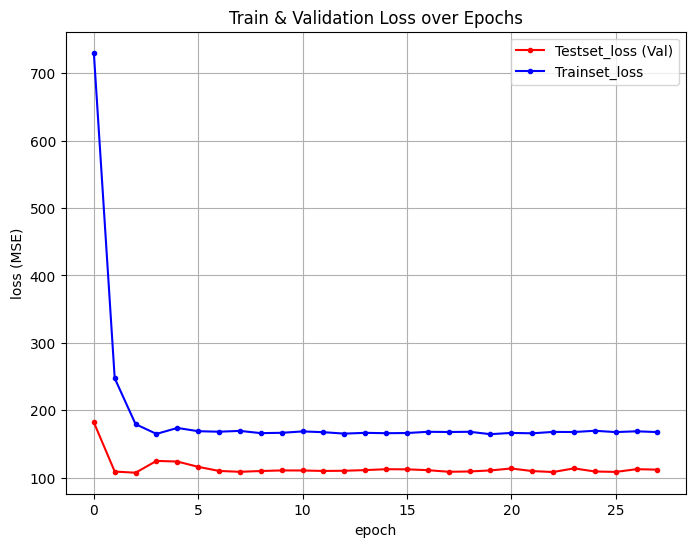

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step

Expected survival :
[[32.04]]


In [18]:
print("Training Start!!")
print("==============================================")
history = model.fit(X_train, y_train,
                    epochs=500,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping_callback],
                    verbose=1)
print("Training finished & Saved")

# 5. 모델 성능 평가 (테스트셋) - "평균 절대 오차(Mean Absolute Error) - 예측값과 실제값이 평균 약 8.32 차이"
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"\nTest Loss (MSE): {test_loss:.4f}, Test MAE: {test_mae:.4f}")

# 6. 학습 과정 그래프 시각화
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

x_len = np.arange(len(y_loss))
plt.figure(figsize=(8, 6))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss (Val)')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss (MSE)')
plt.title('Train & Validation Loss over Epochs')
plt.show()

# 7. 특정 입력 데이터(data_input)에 대한 결과 예측

data_input = np.array([[0, 4, 2, 0, 3, 0]])

# 모델 입력 차원에 맞게 형태 변환 (1 sample, 6 timesteps, 1 feature)
data_input_reshaped = data_input.reshape(1, data_length, 1)

prediction = model.predict(data_input_reshaped)

# 모델이 실제 범위를 바로 학습
expected_survival = prediction[0][0]
print('\nExpected survival :')
print(f"[[{expected_survival:.2f}]]")